#  Climate Change and Extreme Weather Events

**Research Question:** How have the frequency and economic damage of extreme weather events changed
over the past 50 years, and which world regions show the steepest acceleration?

In [62]:
# Bibliotecas
import pandas as pd
import missingno as msno
import pycountry_convert as pc
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Funções
# Filtrar apenas os dados relativos a regiões (continentes) do planeta
def country_to_continent(country_code):
    try:
        country_code_alpha2 = pc.country_alpha3_to_country_alpha2(country_code)
        continent_code = pc.country_alpha2_to_continent_code(country_code_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except Exception as e:
        # TLS - Timor-Leste (Asia), SXM - Sint Maarten (North America)
        if country_code == 'TLS':
            return "Asia"
        if country_code == 'SXM':
            return "North America"
        print(f"Erro ao converter {country_code}: {e}")
        return "Other/Unknown"

### STEP 1: Data Loading, Audit, and Preprocessing

Temos 5 dataset diferentes que vamos limpar e organizar para transformar em um único conjunto de dados para depois fazermos as análises e gráficos.

In [75]:
line = 60 * '-'
ds_names = [
    'average-monthly-surface-temperature',
    'country-level-monthly-temperature-anomalies',
    'economic-damages-from-disasters-as-a-share-of-gdp',
    'number-of-deaths-from-natural-disasters',
    'per-capita-greenhouse-gas-emissions'
]

dfs = []

for ds in ds_names:
    dfs.append(pd.read_csv(f'../data/{ds}/{ds}.csv'))

for i, df in enumerate(dfs):
    n_rows, n_cols = df.shape
    print(f"O dataset {ds_names[i]} tem {n_rows} linhas e {n_cols} colunas.")

# Alias para os datasets
surface_temperature = dfs[0]
temperature_anomalies = dfs[1]
economic_damages = dfs[2]
disaster_deaths = dfs[3]
gas_emissions = dfs[4]

O dataset average-monthly-surface-temperature tem 220242 linhas e 4 colunas.
O dataset country-level-monthly-temperature-anomalies tem 18531 linhas e 15 colunas.
O dataset economic-damages-from-disasters-as-a-share-of-gdp tem 5615 linhas e 13 colunas.
O dataset number-of-deaths-from-natural-disasters tem 7718 linhas e 14 colunas.
O dataset per-capita-greenhouse-gas-emissions tem 36179 linhas e 4 colunas.


In [5]:
for i, df in enumerate(dfs):
    print(f"Dataset Name: {ds_names[i]}")
    print(df.Code.unique(), '\n')

Dataset Name: average-monthly-surface-temperature
['AFG' nan 'ALB' 'DZA' 'ASM' 'AND' 'AGO' 'AIA' 'ATG' 'ARG' 'ARM' 'AUS'
 'AUT' 'AZE' 'BHS' 'BHR' 'BGD' 'BLR' 'BEL' 'BLZ' 'BEN' 'BTN' 'BOL' 'BIH'
 'BWA' 'BRA' 'BRN' 'BGR' 'BFA' 'BDI' 'KHM' 'CMR' 'CAN' 'CPV' 'CYM' 'CAF'
 'TCD' 'CHL' 'CHN' 'COL' 'COM' 'COG' 'COK' 'CRI' 'CIV' 'HRV' 'CUB' 'CYP'
 'CZE' 'COD' 'DNK' 'DJI' 'DOM' 'TLS' 'ECU' 'EGY' 'SLV' 'GNQ' 'ERI' 'EST'
 'SWZ' 'ETH' 'FLK' 'FRO' 'FJI' 'FIN' 'FRA' 'PYF' 'GAB' 'GMB' 'GEO' 'DEU'
 'GHA' 'GRC' 'GRL' 'GTM' 'GIN' 'GNB' 'GUY' 'HTI' 'HMD' 'HND' 'HKG' 'HUN'
 'ISL' 'IND' 'IDN' 'IRN' 'IRQ' 'IRL' 'IMN' 'ISR' 'ITA' 'JAM' 'JPN' 'JOR'
 'KAZ' 'KEN' 'KIR' 'OWID_KOS' 'KWT' 'KGZ' 'LAO' 'LVA' 'LBN' 'LSO' 'LBR'
 'LBY' 'LTU' 'LUX' 'MDG' 'MWI' 'MYS' 'MLI' 'MRT' 'MUS' 'MEX' 'MDA' 'MNG'
 'MNE' 'MAR' 'MOZ' 'MMR' 'NAM' 'NPL' 'NLD' 'NCL' 'NZL' 'NIC' 'NER' 'NGA'
 'PRK' 'MKD' 'NOR' 'OMN' 'PAK' 'PSE' 'PAN' 'PNG' 'PRY' 'PER' 'PHL' 'POL'
 'PRT' 'PRI' 'QAT' 'ROU' 'RUS' 'RWA' 'SHN' 'VCT' 'WSM' 'STP' 'SAU' 'SEN'
 'SR

### Análise do dataset **Average monthly surface temperature**

In [19]:
surface_temperature.head()

,Entity,Code,Day,Monthly average
0,Afghanistan,AFG,1940-01-15,-2.032494
1,Afghanistan,AFG,1940-02-15,-0.733503
2,Afghanistan,AFG,1940-03-15,1.999134
3,Afghanistan,AFG,1940-04-15,10.199754
4,Afghanistan,AFG,1940-05-15,17.942135


In [60]:
# 1. Converter a coluna 'Day' para o formato datetime
surface_temperature['Day'] = pd.to_datetime(surface_temperature['Day'])

# 2. Criar a nova coluna 'Year' extraindo apenas o ano (formato YYYY)
surface_temperature['Year'] = surface_temperature['Day'].dt.strftime('%Y')

# Agrupando por Ano e Código, calculando média e mediana para comparação
surface_temperature_1 = surface_temperature.groupby(['Year', 'Code'])['Monthly average'].mean().reset_index()

# Renomeando as colunas para clareza
surface_temperature_1.columns = ['Year', 'Code', 'Yearly average']

# Visualizar o resultado
print(surface_temperature_1.head(), '\n')

# Eliminar as linhas que correspondem a regiões globais (OWID) e adicionar uma coluna de região (continente)
surface_temperature_2 = surface_temperature_1[~surface_temperature_1.Code.str.startswith('OWID')].copy()
surface_temperature_2['Region'] = surface_temperature_2['Code'].apply(country_to_continent)

# Converter a coluna 'Year' para inteiro
surface_temperature_2['Year'] = surface_temperature_2['Year'].astype(int)

# Agrupar os dados por região e ano, somando os valores dos desastres para cada região
surface_temperature_2 = surface_temperature_2.drop(columns=['Code'])
surface_temperature_2 = surface_temperature_2.groupby(['Region', 'Year'])['Yearly average'].median().reset_index()

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
surface_temperature_2 = surface_temperature_2[surface_temperature_2['Year'].between(1975, 2024)]

surface_temperature_2.info()
surface_temperature_2.describe()
surface_temperature_2.head()

   Year Code  Yearly average
0  1940  AFG       11.327695
1  1940  AGO       21.409697
2  1940  AIA       25.821704
3  1940  ALB       10.648014
4  1940  AND        3.409269 

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 35 to 606
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          350 non-null    object 
 1   Year            350 non-null    int64  
 2   Yearly average  350 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 10.9+ KB


,Region,Year,Yearly average
35,Africa,1975,23.463053
36,Africa,1976,23.532817
37,Africa,1977,23.945950
38,Africa,1978,23.778325
39,Africa,1979,23.850431


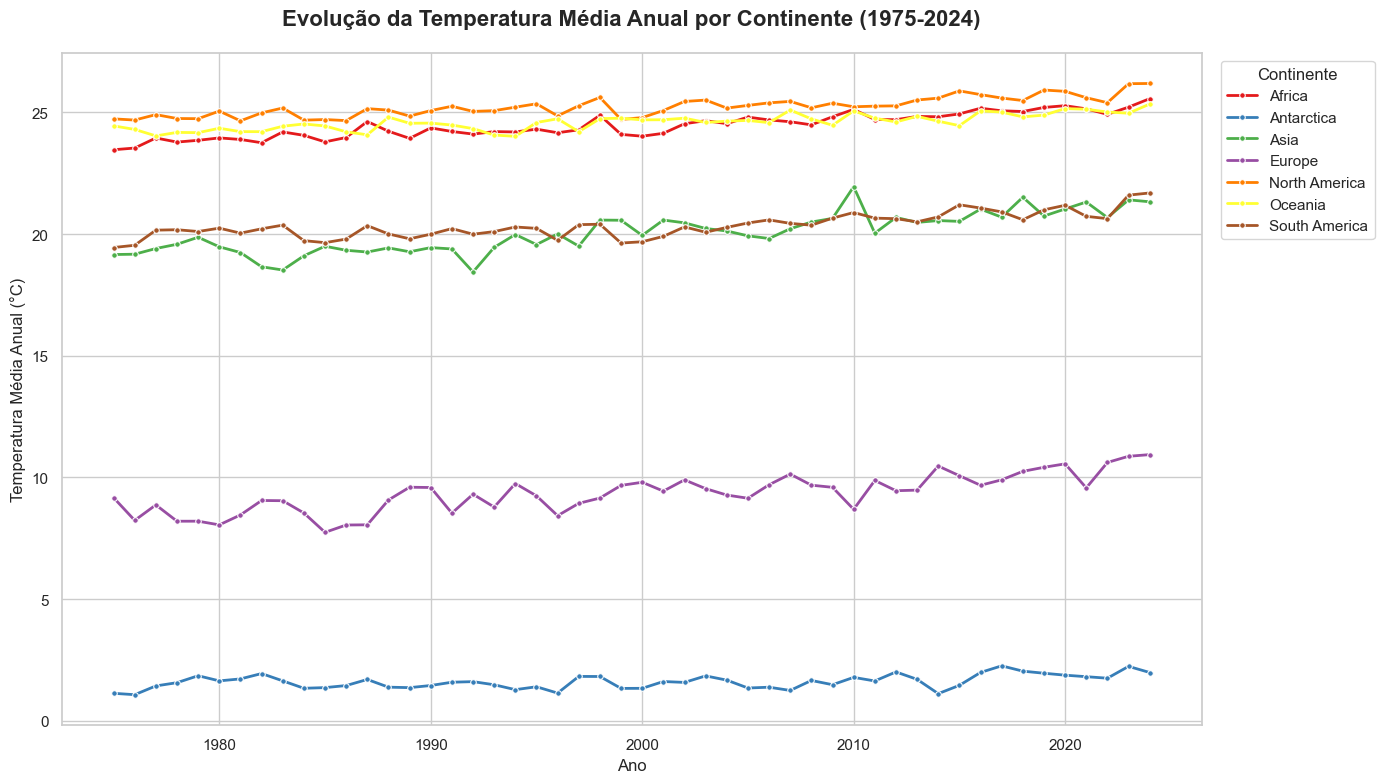

In [64]:
# Criar um gráfico de linhas para mostrar a evolução das temperaturas médias anuais por continente
# 1. Configurar o estilo visual para ficar profissional (padrão IEEE)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

# 2. Criar o gráfico de linhas
# 'hue' define uma cor diferente para cada continente (Region)
line_plot = sns.lineplot(
    data=surface_temperature_2, 
    x='Year', 
    y='Yearly average', 
    hue='Region', 
    marker='o',         # Adiciona marcadores nos pontos anuais
    markersize=4, 
    linewidth=2,
    palette='Set1'      # Paleta de cores com alto contraste
)

# 3. Customização e Títulos
plt.title('Evolução da Temperatura Média Anual por Continente (1975-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Temperatura Média Anual (°C)', fontsize=12)

# 4. Ajustar a Legenda para fora do gráfico para não obstruir os dados
plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Ajuste fino do layout e exibição
plt.tight_layout()
plt.show()

### Análise do datase **Country level monthly temperature anomalies**

In [65]:
temperature_anomalies.head()

,Entity,Code,Year,January,February,March,April,May,June,July,August,September,October,November,December
0,Afghanistan,AFG,1940,-0.789005,-1.594132,-4.561447,-2.868090,-0.813093,0.006361,-0.850492,-1.840513,-1.719229,0.608858,-0.174298,0.167288
1,Afghanistan,AFG,1941,-1.396612,1.839120,0.525898,-0.109256,1.631727,1.473896,0.133833,0.881645,-0.350918,2.870823,0.891722,1.145056
2,Afghanistan,AFG,1942,0.578493,-0.183040,0.761576,0.712292,1.280947,0.068129,0.535709,-0.487333,-0.290590,1.114729,2.106128,-1.931792
3,Afghanistan,AFG,1943,-2.199644,-2.021629,-1.286101,-3.617765,-2.613882,-1.148052,0.082497,-0.607708,-0.366194,-0.684995,0.362292,2.038275
4,Afghanistan,AFG,1944,-0.124280,-0.487659,0.154415,-0.629282,0.376087,-0.226828,1.443995,0.210638,-1.555296,-0.398036,0.714622,-4.114528


In [90]:
# 1. Definir a lista de colunas dos meses
colunas_meses = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]

# 2. Calcular a média anual apenas para estas colunas e criar a nova coluna
# O axis=1 indica que a média é calculada horizontalmente (para cada linha)
temperature_anomalies['Yearly_anomaly_average'] = temperature_anomalies[colunas_meses].mean(axis=1)
temperature_anomalies_1 = temperature_anomalies.drop(columns=colunas_meses)

regions = [
    'Africa (NIAID)', 'Asia (NIAID)', 'Europe (NIAID)', 
    'North America (NIAID)', 'South America (NIAID)', 'Oceania (NIAID)'
]

# 2. Filtrar o DataFrame para manter apenas essas entidades
temperature_anomalies_2 = temperature_anomalies_1[temperature_anomalies_1['Entity'].isin(regions)].copy()

# 3. Limpar os nomes (remover o " (NIAID)") para facilitar a visualização
temperature_anomalies_2['Entity'] = temperature_anomalies_2['Entity'].str.replace(' (NIAID)', '', regex=False)

# Eliminar a coluna code
temperature_anomalies_3 = temperature_anomalies_2.drop(columns=['Code'])

# Renomeando as colunas para clareza
temperature_anomalies_3.columns = ['Region', 'Year', 'Yearly anomaly average']

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
temperature_anomalies_3 = temperature_anomalies_3[temperature_anomalies_3['Year'].between(1975, 2024)]

# 4. Verificar o resultado
temperature_anomalies_3.head()

,Region,Year,Yearly anomaly average
122,Africa,1975,-1.207231
123,Africa,1976,-1.228984
124,Africa,1977,-0.872081
125,Africa,1978,-0.863768
126,Africa,1979,-0.628132


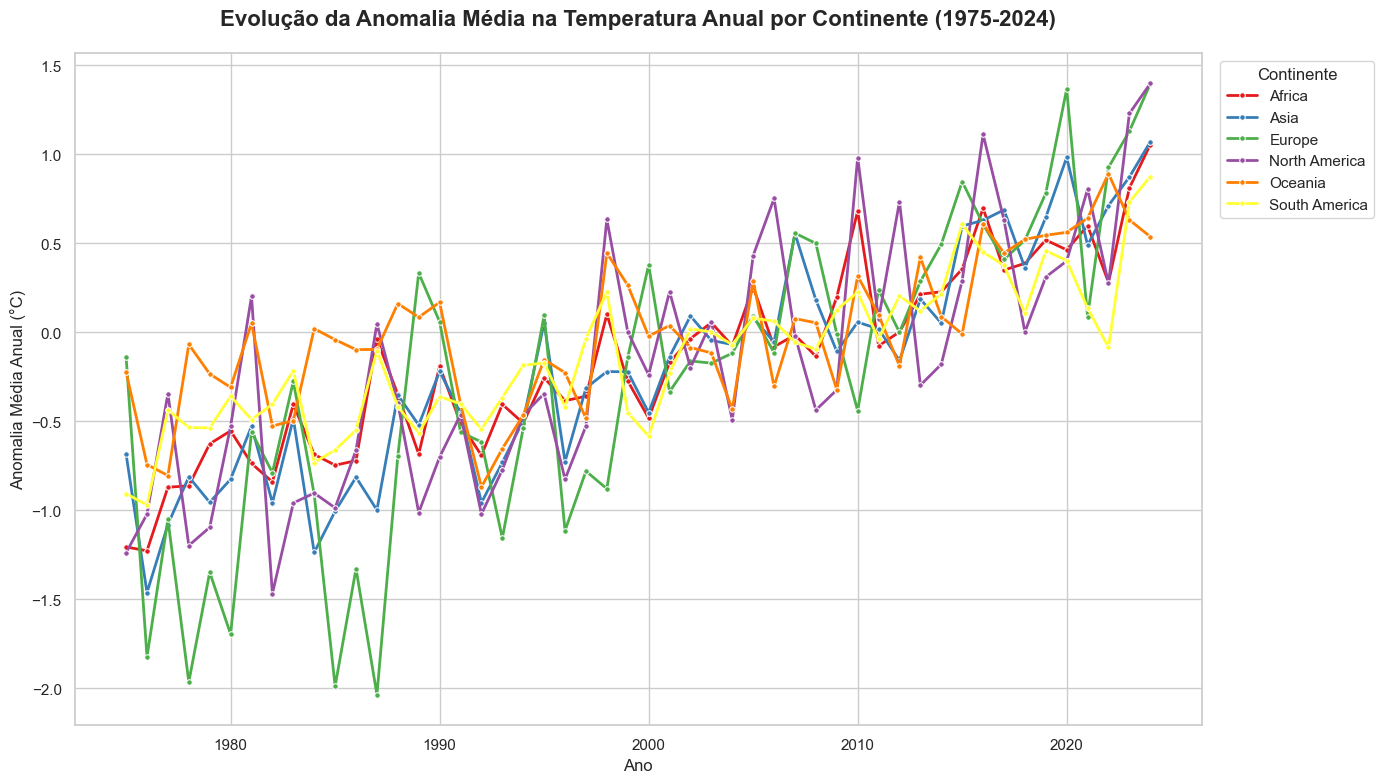

In [91]:
# Criar um gráfico de linhas para mostrar a evolução das anomalias médias nas temperaturas médias anuais por continente
# 1. Configurar o estilo visual para ficar profissional (padrão IEEE)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

# 2. Criar o gráfico de linhas
# 'hue' define uma cor diferente para cada continente (Region)
line_plot = sns.lineplot(
    data=temperature_anomalies_3, 
    x='Year', 
    y='Yearly anomaly average', 
    hue='Region', 
    marker='o',         # Adiciona marcadores nos pontos anuais
    markersize=4, 
    linewidth=2,
    palette='Set1'      # Paleta de cores com alto contraste
)

# 3. Customização e Títulos
plt.title('Evolução da Anomalia Média na Temperatura Anual por Continente (1975-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Anomalia Média Anual (°C)', fontsize=12)

# 4. Ajustar a Legenda para fora do gráfico para não obstruir os dados
plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Ajuste fino do layout e exibição
plt.tight_layout()
plt.show()

### Análise do dataset **Economic damages from disasters as a share of GDP (%)**

Este dataset são os danos económicos (em % do GDP relativa a cada país) que os desastres causaram entre 1975 e 2024 (50 anos).

Os dados contém 13 colunas e 5.615 linhas. A coluna Entity apresenta o nome de 199 países mais 6 agrupamentos (o mundo todo e mais grupos classficados de acordo com a receita do país). A coluna Code é o respectivo código da Entity. As restantes colunas, além do ano, são os valores de dano por tipo de desastre. Como nem todos os desastres estão relacionados com as condições climáticas, resolvemos eliminar as colunas [Earthquakes, Volcanoes, Glacial lake outbursts, Mass movement (dry), Mass movement (wet)], ficando apenas com [Droughts, Floods, Storms, Extreme temperatures, Wildfires].

Como os danos económicos estão em porcentagem do PIB de cada país, para que possamos agrupá-los por continente, antes é preciso converter estes dados em valores monetários para depois comparar com o PIB do continente, ou conseguir fazer uma média ponderada do PIB de cada país. Desta forma, como esta análise é um pouco mais trabalhosa, ainda não tempos gráficos iniciais para tal dataset.

O dano total é definido como o valor de todas as perdas econômicas direta ou indiretamente causadas pelo desastre, sem ajuste pela inflação.

Citação em linha:

> EM-DAT, CRED / UCLouvain (2025); National statistical organizations and central banks, OECD national accounts, and World Bank staff estimates (2025) – with major processing by Our World in Data

Citação completa:

> EM-DAT, CRED / UCLouvain (2025); National statistical organizations and central banks, OECD national accounts, and World Bank staff estimates (2025) – with major processing by Our World in Data. “Annual economic damages as a share of GDP from droughts – EM-DAT” [dataset]. EM-DAT, “The International Disasters Database”; National statistical organizations and central banks, OECD national accounts, and World Bank staff estimates, “World Development Indicators 122” [original data].

In [111]:
# Manter apenas as colunas que representam tipos de desastres que podem estar ligados a mudanças climáticas
economic_damages.info()

print('\n' + line + '\n')

print(economic_damages.describe())

# Manter apenas as colunas 0, 1 e 2, 3, 4, 6, 7 e 9
economic_damages_1 = economic_damages.iloc[:, [0, 1, 2, 3, 4, 6, 7, 9]].copy()

# economic_damages_1.iloc[:, 3:8].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5615 entries, 0 to 5614
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Entity                  5615 non-null   object 
 1   Code                    5615 non-null   object 
 2   Year                    5615 non-null   int64  
 3   Droughts                1499 non-null   float64
 4   Floods                  3436 non-null   float64
 5   Earthquakes             1104 non-null   float64
 6   Storms                  2399 non-null   float64
 7   Extreme temperatures    886 non-null    float64
 8   Volcanoes               382 non-null    float64
 9   Wildfires               575 non-null    float64
 10  Glacial lake outbursts  13 non-null     float64
 11  Mass movement (dry)     94 non-null     float64
 12  Mass movement (wet)     851 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 570.4+ KB

--------------------------------

In [57]:
# Eliminar as linhas que correspondem a regiões globais (OWID) e adicionar uma coluna de região (continente)
economic_damages_2 = economic_damages_1[~economic_damages_1.Code.str.startswith('OWID')].copy()
economic_damages_2['Region'] = economic_damages_2['Code'].apply(country_to_continent)

# Agrupar os dados por região e ano, somando os valores dos desastres para cada região
economic_damages_2 = economic_damages_2.drop(columns=['Code', 'Entity'])
# economic_damages_2 = economic_damages_2.groupby(['Region', 'Year']).agg(['mean', 'median', 'max']).reset_index()
economic_damages_2 = economic_damages_2.groupby(['Region', 'Year']).median().reset_index()

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
economic_damages_2 = economic_damages_2[economic_damages_2['Year'].between(1975, 2024)]

economic_damages_2.info()
economic_damages_2.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 15 to 384
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Region                300 non-null    object 
 1   Year                  300 non-null    int64  
 2   Droughts              235 non-null    float64
 3   Floods                290 non-null    float64
 4   Storms                284 non-null    float64
 5   Extreme temperatures  157 non-null    float64
 6   Wildfires             187 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 18.8+ KB


,Year,Droughts,Floods,Storms,Extreme temperatures,Wildfires
count,300.000000,235.000000,290.000000,284.000000,157.000000,187.000000
mean,1999.500000,0.153173,0.048732,0.232884,0.091397,0.483586
std,14.454981,0.671257,0.304165,0.921362,0.976513,4.772964
min,1975.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1987.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1999.500000,0.000000,0.000000,0.002998,0.000000,0.000000
75%,2012.000000,0.063848,0.009660,0.047691,0.000000,0.015023
max,2024.000000,9.224813,4.779224,7.418616,12.226847,63.638820


In [8]:
missing = economic_damages_2.isnull().sum()
pct = (missing / len(economic_damages_2) * 100).round(1)
summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
})

if summary['missing_count'].sum() == 0:
    print("Não há valores ausentes no dataset.")
else:
    print("Valores ausentes por coluna:")
    print(summary[summary['missing_count'] > 0])

Valores ausentes por coluna:
                      missing_count  missing_pct
Droughts                         65         21.7
Floods                           10          3.3
Storms                           16          5.3
Extreme temperatures            143         47.7
Wildfires                       113         37.7


In [9]:
duplicates = economic_damages_2.duplicated().sum()

print(f"Número de linhas duplicadas: {duplicates}")

Número de linhas duplicadas: 0


In [108]:
economic_damages_2.head()
economic_damages_2.describe()

,Year,Droughts,Floods,Storms,Extreme temperatures,Wildfires,Total_Damage_GDP
count,300.000000,235.000000,290.000000,284.000000,157.000000,187.000000,299.000000
mean,1999.500000,0.153173,0.048732,0.232884,0.091397,0.483586,0.192770
std,14.454981,0.671257,0.304165,0.921362,0.976513,4.772964,0.886752
min,1975.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1987.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001389
50%,1999.500000,0.000000,0.000000,0.002998,0.000000,0.000000,0.017870
75%,2012.000000,0.063848,0.009660,0.047691,0.000000,0.015023,0.078495
max,2024.000000,9.224813,4.779224,7.418616,12.226847,63.638820,12.863619


### Análise do dataset **Number of deaths from natural disasters**

In [133]:
disaster_deaths.info()

dd_columns = ['Droughts', 'Floods', 'Storms', 'Extreme temperatures', 'Wildfires']
dd_columns_to_drop = [
    'Earthquakes', 'Volcanoes', 'Glacial lake outbursts', 
    'Mass movements (dry)', 'Mass movements (wet)', 'Fogs'
]

continents = ['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania']

disaster_deaths_1 = disaster_deaths.drop(columns=dd_columns_to_drop)

# Filtrar o DataFrame para manter apenas essas entidades
disaster_deaths_2 = disaster_deaths_1[disaster_deaths_1['Entity'].isin(regions)].copy()

# Agrupar os dados por região e ano, somando os valores dos desastres para cada região
disaster_deaths_2 = disaster_deaths_2.groupby(['Entity', 'Year']).sum().reset_index()

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
disaster_deaths_2 = disaster_deaths_2[disaster_deaths_2['Year'].between(1975, 2024)]

disaster_deaths_2 = disaster_deaths_2.drop(columns=['Code'])

# Alterar o nome das colunas 
disaster_deaths_2.columns = ['Region', 'Year', 'Droughts', 'Floods', 'Storms', 'Extreme temperatures', 'Wildfires']

# Testar o resultado
print(disaster_deaths_2.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7718 entries, 0 to 7717
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Entity                  7718 non-null   object 
 1   Code                    7718 non-null   object 
 2   Year                    7718 non-null   int64  
 3   Droughts                2061 non-null   float64
 4   Floods                  4315 non-null   float64
 5   Earthquakes             2080 non-null   float64
 6   Storms                  3547 non-null   float64
 7   Extreme temperatures    1102 non-null   float64
 8   Volcanoes               654 non-null    float64
 9   Wildfires               844 non-null    float64
 10  Glacial lake outbursts  26 non-null     float64
 11  Mass movements (dry)    153 non-null    float64
 12  Mass movements (wet)    1227 non-null   float64
 13  Fogs                    4 non-null      float64
dtypes: float64(11), int64(1), object(2)
memo

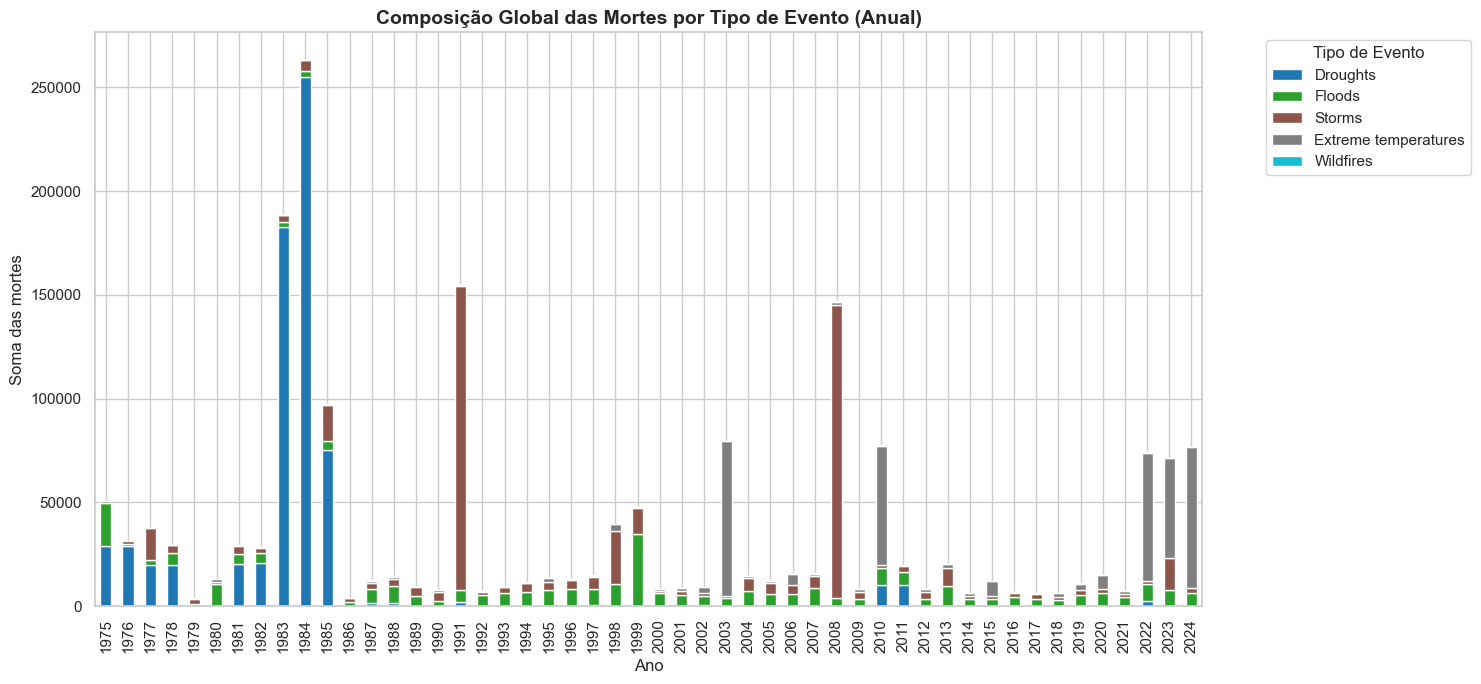

In [135]:
# Agrupar por Ano e somar as mortes globais de cada tipo
df_dd_year = disaster_deaths_2.groupby('Year')[dd_columns].sum()

# 3. Plotar barras empilhadas
df_dd_year.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='tab10')

plt.title('Composição Global das Mortes por Tipo de Evento (Anual)', fontsize=14, fontweight='bold')
plt.ylabel('Soma das mortes', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.legend(title='Tipo de Evento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

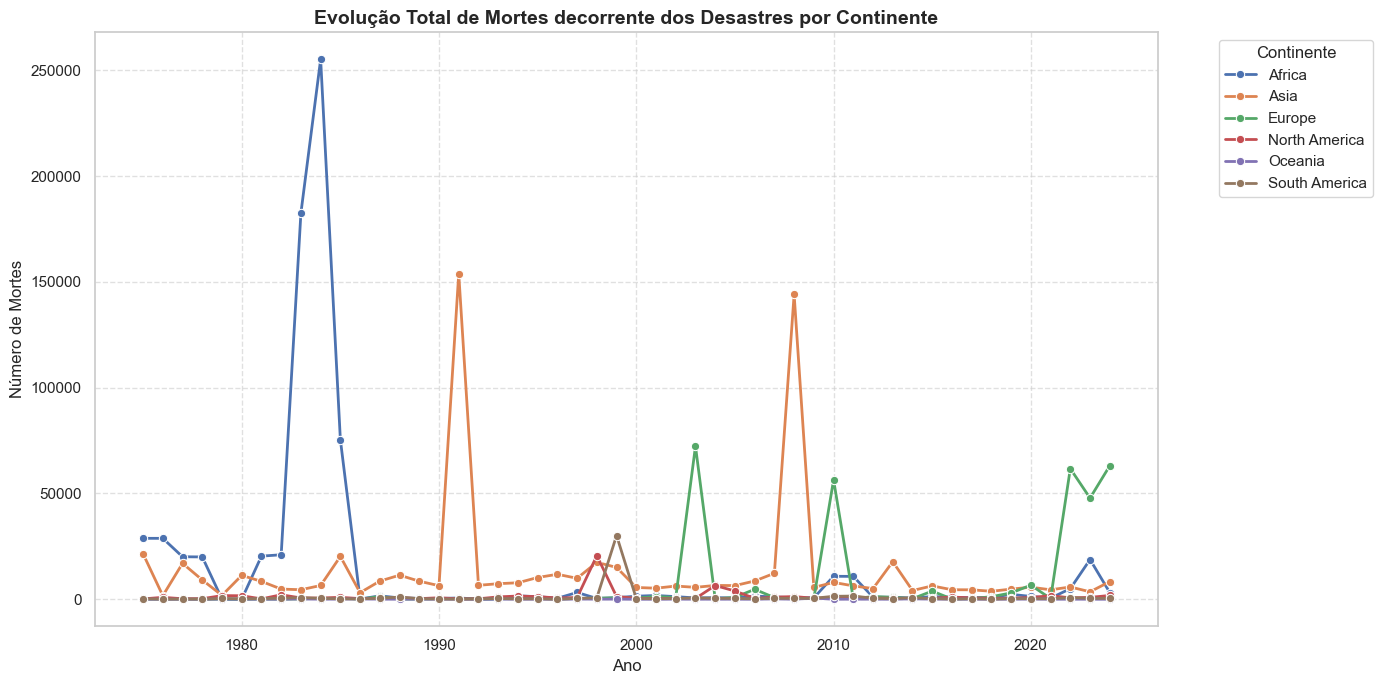

In [142]:
# 1. Criar uma coluna com a soma de todos os tipos de danos para cada linha
disaster_deaths_2['Total_Deaths'] = disaster_deaths_2[dd_columns].sum(axis=1)

# 2. Filtrar apenas os continentes desejados
df_continents_line = disaster_deaths_2[disaster_deaths_2['Region'].isin(continents)]

# 3. Gráfico de linhas com Seaborn
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_continents_line, x='Year', y='Total_Deaths', hue='Region', marker='o', linewidth=2)

plt.title('Evolução Total de Mortes decorrente dos Desastres por Continente', fontsize=14, fontweight='bold')
plt.ylabel('Número de Mortes', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Continente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Análise do dataset **Per capita greenhouse gas emissions**

Greenhouse gases são os gases que contribuem para o efeito estufa (CO<sub>2</sub>, Metano e Óxido Nitroso). Os dados contém os a quantidade em toneladas per capita destes gases emitidas por cada país e em cada ano. Também é importante salientar que as emissões são referentes a produção humana destes gases, incluindo a queima de combustíveis fósseis, a atividade industrial e a produção de alimentos.

Citação em linha:

Jones et al. (2025); Population based on various sources (2024) – with major processing by Our World in Data

Citação completa:

Jones et al. (2025); Population based on various sources (2024) – with major processing by Our World in Data. “Per capita greenhouse gas emissions including land use” [dataset]. Jones et al., “National contributions to climate change 2025.1”; Various sources, “Population” [original data].

In [152]:
gas_emissions.info()

continent_codes = ['OWID_AFR', 'OWID_ASI', 'OWID_EUR', 'OWID_NAM', 'OWID_OCE', 'OWID_SAM']

gas_emissions_1 = gas_emissions[gas_emissions.Code.isin(continent_codes)].copy()

gas_emissions_1.columns = ['Region', 'Code', 'Year', 'Greenhouse gas emissions']

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
gas_emissions_1 = gas_emissions_1[gas_emissions_1['Year'].between(1975, 2024)]
gas_emissions_1 = gas_emissions_1.drop(columns=['Code'])

gas_emissions_1.describe()

gas_emissions_1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36179 entries, 0 to 36178
Data columns (total 4 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Entity                                                  36179 non-null  object 
 1   Code                                                    36179 non-null  object 
 2   Year                                                    36179 non-null  int64  
 3   Per capita greenhouse gas emissions including land use  36179 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ MB


,Region,Year,Greenhouse gas emissions
300,Africa,1975,4.913611
301,Africa,1976,4.915044
302,Africa,1977,5.011398
303,Africa,1978,4.752050
304,Africa,1979,4.752768


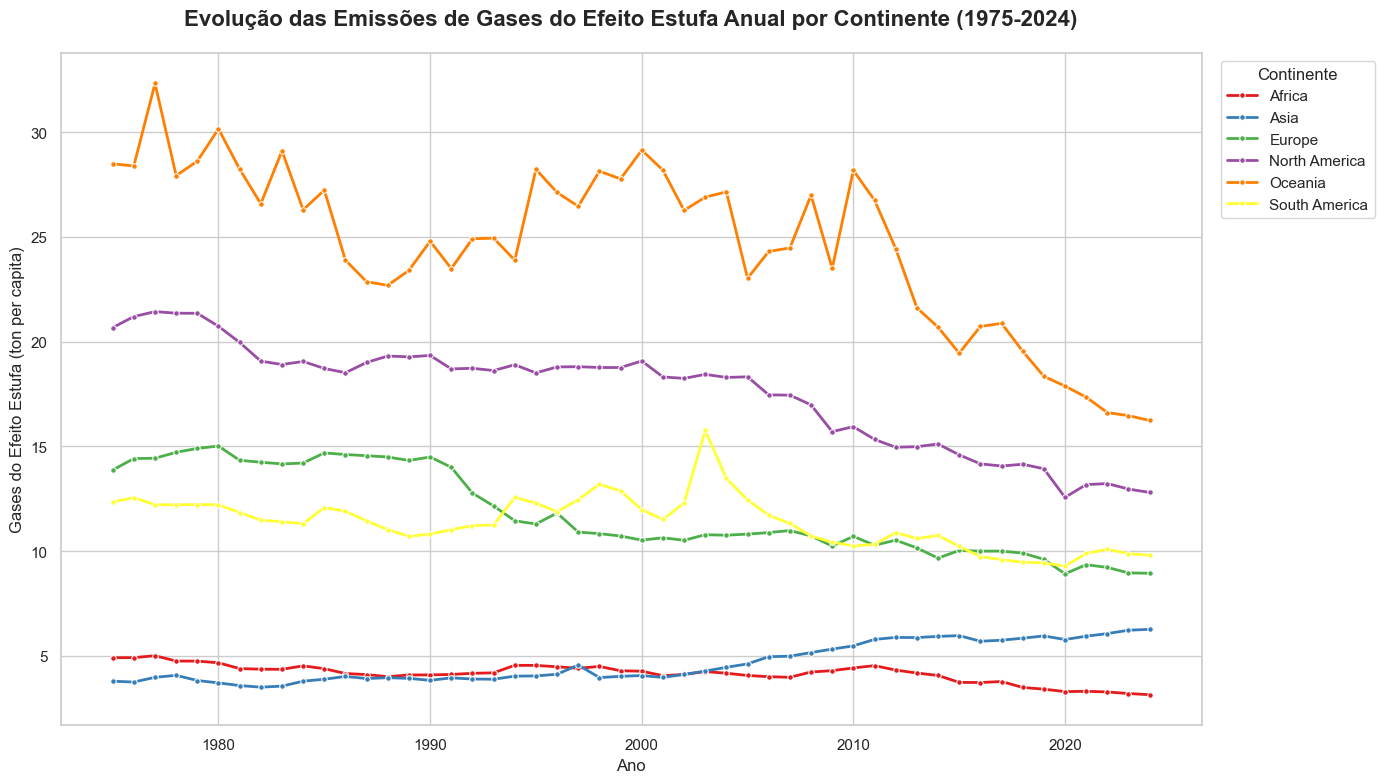

In [154]:
# Criar um gráfico de linhas para mostrar a evolução das anomalias médias nas temperaturas médias anuais por continente
# 1. Configurar o estilo visual para ficar profissional (padrão IEEE)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

# 2. Criar o gráfico de linhas
# 'hue' define uma cor diferente para cada continente (Region)
line_plot = sns.lineplot(
    data=gas_emissions_1, 
    x='Year', 
    y='Greenhouse gas emissions', 
    hue='Region', 
    marker='o',         # Adiciona marcadores nos pontos anuais
    markersize=4, 
    linewidth=2,
    palette='Set1'      # Paleta de cores com alto contraste
)

# 3. Customização e Títulos
plt.title('Evolução das Emissões de Gases do Efeito Estufa Anual por Continente (1975-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Gases do Efeito Estufa (ton per capita)', fontsize=12)

# 4. Ajustar a Legenda para fora do gráfico para não obstruir os dados
plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Ajuste fino do layout e exibição
plt.tight_layout()
plt.show()